# ⛽ Case 1 dataset

In [ ]:
import os

# # Set KaggleHub cache to a directory inside /content/
os.environ["KAGGLEHUB_CACHE"] = "/content/data"

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("debarghamitraroy/face-mask-detection")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'face-mask-detection' dataset.
Path to dataset files: /kaggle/input/face-mask-detection


# ✅ Script to discover data folder structure

In [ ]:
from pathlib import Path

def print_tree(directory, prefix='', limit=10):
    path_obj = Path(directory)

    try:
        # Get all items and separate them into dirs and files
        items = list(path_obj.iterdir())
        dirs = sorted([x for x in items if x.is_dir()], key=lambda x: x.name.lower())
        files = sorted([x for x in items if x.is_file()], key=lambda x: x.name.lower())
    except PermissionError:
        print(f"{prefix}[Access Denied]")
        return

    # We will print ALL directories, but only a sample of files
    files_to_show = files[:limit]
    remaining_files = len(files) - limit

    # Combine lists for the loop
    # We loop through all dirs + the sample of files
    display_items = dirs + files_to_show

    pointers = [('├── ', '│   '), ('└── ', '    ')]

    for i, item in enumerate(display_items):
        # It is the "last" item only if there are no remaining hidden files
        is_last_item = (i == len(display_items) - 1) and (remaining_files <= 0)

        connector, next_prefix = pointers[1] if is_last_item else pointers[0]

        print(f"{prefix}{connector}{item.name}")

        if item.is_dir():
            print_tree(item, prefix + next_prefix, limit)

    # If we cut off files, print the summary as the true last item
    if remaining_files > 0:
        print(f"{prefix}└── ... ({remaining_files} more files)")


print_tree(path, limit=10)

├── data
│   ├── with_mask
│   │   ├── with_mask_1.jpg
│   │   ├── with_mask_10.jpg
│   │   ├── with_mask_100.jpg
│   │   ├── with_mask_1000.jpg
│   │   ├── with_mask_1001.jpg
│   │   ├── with_mask_1002.jpg
│   │   ├── with_mask_1003.jpg
│   │   ├── with_mask_1004.jpg
│   │   ├── with_mask_1005.jpg
│   │   ├── with_mask_1006.jpg
│   │   └── ... (9598 more files)
│   └── without_mask
│       ├── without_mask_1.jpg
│       ├── without_mask_10.jpg
│       ├── without_mask_100.jpg
│       ├── without_mask_1000.jpg
│       ├── without_mask_1001.jpg
│       ├── without_mask_1002.jpg
│       ├── without_mask_1003.jpg
│       ├── without_mask_1004.jpg
│       ├── without_mask_1005.jpg
│       ├── without_mask_1006.jpg
│       └── ... (9727 more files)
└── eval
    ├── classes.csv
    ├── test_1.jpg
    ├── test_10.jpg
    ├── test_100.jpg
    ├── test_1000.jpg
    ├── test_1001.jpg
    ├── test_1002.jpg
    ├── test_1003.jpg
    ├── test_1004.jpg
    ├── test_1005.jpg
    └── ... (1270 more fi

# ⏩ CSV for the images path and labels

This only for test dataset inside eval/classes.csv"

In [ ]:
import pandas as pd
import os

classes_path = os.path.join(path,"eval" ,"classes.csv")
classes_df = pd.read_csv(classes_path)
classes_df.tail()
#

,filename,with_mask,without_mask
1274,test_599.jpg,0,1
1275,test_843.jpg,0,1
1276,test_365.jpg,0,1
1277,test_394.jpg,1,0
1278,test_545.jpg,0,1


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os
import pandas as pd

class MaskDetectionDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.dataframe = dataframe
        self.img_dir = img_dir
        self.transform = transform

        # Create a single label column from 'with_mask' and 'without_mask'
        # Assuming 1 for 'with_mask' and 0 for 'without_mask'
        self.labels = self.dataframe.apply(lambda row: 1 if row['with_mask'] == 1 else 0, axis=1)

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_name = self.dataframe.iloc[idx, 0] # 'filename' column
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert('RGB') # Ensure 3 channels
        label = self.labels.iloc[idx]

        if self.transform:
            image = self.transform(image)

        return image, label




In [ ]:
# # Define the image transformations (using the existing `trasnform` from cell U6rjmbeTAydj)
# # Make sure `trasnform` is defined in a previous cell or copied here if needed.
# # For demonstration, let's redefine it here to ensure independence if this cell is run alone.
# from torchvision import transforms
# from sklearn.model_selection import train_test_split


# trasnform = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.ToTensor(),
# ])


# image_directory = os.path.join(path, "eval")



# train_df, test_df = train_test_split(classes_df, test_size=0.2)






# train_dataset = MaskDetectionDataset(dataframe=train_df, img_dir=image_directory, transform=trasnform)
# test_dataset = MaskDetectionDataset(dataframe=test_df, img_dir=image_directory, transform=trasnform)


# print(f"Number of items in train dataset: {len(train_dataset)}")
# print(f"Number of items in test dataset: {len(test_dataset)}")


# batch_size = 32
# train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
# test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)


# print('------------------------------')
# images, labels = next(iter(test_loader))
# print(f"Batch shape: {images.shape}, Labels: {labels}")

Number of items in train dataset: 1023
Number of items in test dataset: 256
------------------------------
Batch shape: torch.Size([32, 3, 224, 224]), Labels: tensor([1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
        0, 0, 0, 0, 0, 0, 0, 1])


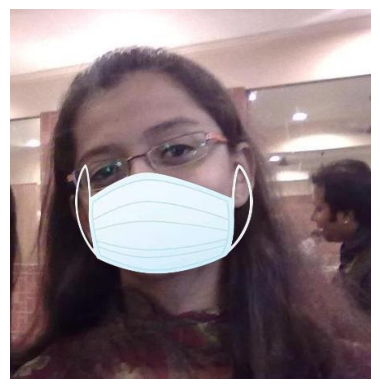

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os

image_path = os.path.join(path, "eval", "test_309.jpg")
image = Image.open(image_path)

plt.imshow(image)
plt.axis('off') # Hide axes ticks
plt.show()

# ⛳ Data class using ImageFolder

dataset_root/
├── class_A/
│   ├── img1.jpg
│   ├── img2.jpg
│   └── ...
├── class_B/
│   ├── img1.jpg
│   ├── img2.jpg
│   └── ...


In [ ]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

dataset_path = os.path.join(path)

dataset = ImageFolder(dataset_path, transform=transform)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)



image , label = next(iter(train_loader))
print(f"Batch shape: {image.shape}, Labels: {label}")



Batch shape: torch.Size([32, 3, 224, 224]), Labels: tensor([0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 1, 0, 0, 0, 0, 1, 0])


In [ ]:
import torch.nn as nn
import torch

# Define the CNN Model
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        # Convolutional Layers
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        # Activation
        self.relu = nn.ReLU()

        # Pooling Layer
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fully Connected Layers
        # Corrected input features for fc1 based on (64 * 28 * 28)
        self.fc1 = nn.Linear(64 * 28 * 28, 128)
        # Corrected output features for binary classification (mask/no mask)
        self.fc2 = nn.Linear(128, 2)

    def forward(self, x):
        # Convolution + ReLU + Pooling
        x = self.pool(self.relu(self.conv1(x)))  # (Batch, 16, 112, 112)
        x = self.pool(self.relu(self.conv2(x)))  # (Batch, 32, 56, 56)
        x = self.pool(self.relu(self.conv3(x)))  # (Batch, 64, 28, 28)

        # Flatten
        x = x.view(x.size(0), -1)  # (Batch, 64*28*28)

        # Fully Connected Layers
        x = self.relu(self.fc1(x))
        x = self.fc2(x)  # Logits

        return x

In [ ]:
from tqdm import tqdm    # Shows progress bar

# 🔹 Training Loop
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()  # Set model to training mode
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(dataloader):
        images, labels = images.to(device), labels.to(device)


        outputs = model(images)  # Forward pass
        loss = criterion(outputs, labels)  # Compute loss

        optimizer.zero_grad()  # Reset gradients
        loss.backward()  # Backpropagation
        optimizer.step()  # Update weights

        total_loss += loss.item()

        # Track accuracy
        outputs = torch.softmax(outputs, dim=1)
        predictions = outputs.argmax(dim=1)  # Get class with highest probability
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct / total  # Compute accuracy in percentage
    return avg_loss, accuracy




def validate(model, dataloader, criterion, device):
    model.eval()  # Set model to evaluation mode
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():  # Disable gradient computation
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)  # Forward pass
            loss = criterion(outputs, labels)  # Compute loss
            total_loss += loss.item()

            # Compute accuracy
            outputs = torch.softmax(outputs, dim=1)
            predictions = outputs.argmax(dim=1)  # Get predicted class
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct / total  # Compute accuracy in percentage
    return avg_loss, accuracy

In [ ]:
import torch.optim as optim

# Initialize the model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNModel().to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()  # Multi-class Classification loss (Input: Logits, not probabilities)
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Adam optimizer
num_epochs = 10 # Number of epochs






# Lists to store metrics
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Training process
for epoch in range(num_epochs):
    train_loss, train_accuracy = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_accuracy = validate(model, test_loader, criterion, device)

    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(f"Epoch {epoch+1}/{num_epochs}: "
          f"Train Loss={train_loss:.4f}, Train Accuracy={train_accuracy:.2f}%, "
          f"Val Loss={val_loss:.4f}, Val Accuracy={val_accuracy:.2f}%")

  7%|▋         | 38/516 [00:10<01:58,  4.04it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
100%|██████████| 516/516 [02:04<00:00,  4.13it/s]


Epoch 1/10: Train Loss=0.1870, Train Accuracy=93.42%, Val Loss=0.1540, Val Accuracy=93.99%


 41%|████      | 210/516 [00:25<00:37,  8.16it/s]


KeyboardInterrupt: 

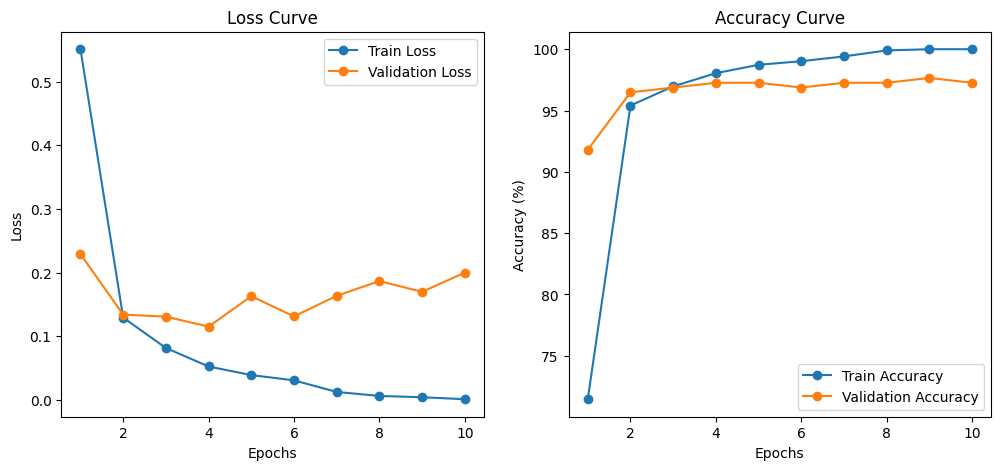

In [ ]:
import matplotlib.pyplot as plt

# Plot loss curve
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), train_losses, label="Train Loss", marker='o')
plt.plot(range(1, num_epochs+1), val_losses, label="Validation Loss", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

# Plot accuracy curve
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), train_accuracies, label="Train Accuracy", marker='o')
plt.plot(range(1, num_epochs+1), val_accuracies, label="Validation Accuracy", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Curve")
plt.legend()

plt.show()

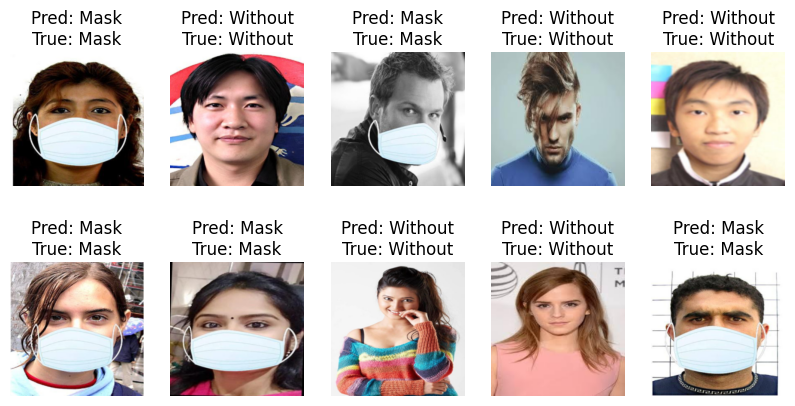

In [ ]:
import numpy as np

# Function to display images with predicted labels
def show_predictions(model, dataloader, device, num_images=10):
    model.eval()  # Set to evaluation mode
    images, labels = next(iter(dataloader))  # Get a batch
    images, labels = images.to(device), labels.to(device)

    with torch.no_grad():  # Disable gradient computation
        outputs = model(images)
        predictions = outputs.argmax(dim=1)  # Get predicted class

    # CIFAR-10 class names
    classes = ['Without', 'Mask',]

    # Plot images with predictions
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for i, ax in enumerate(axes.flat[:num_images]):
        img = images[i]
        img = np.transpose(img.cpu().numpy(), (1, 2, 0))  # Convert to (H, W, C)

        ax.imshow(img)
        ax.set_title(f"Pred: {classes[predictions[i].item()]}\nTrue: {classes[labels[i].item()]}")
        ax.axis("off")

    plt.show()

# Show predictions
show_predictions(model, test_loader, device)

# ▶ Predict new unseen images

In [ ]:
import torch
from PIL import Image
from torchvision import transforms

def predict_image(image_path, model, transform, device):
    """
    Predicts the class of an image given its path.

    Args:
        image_path (str): The path to the image file.
        model (torch.nn.Module): The trained PyTorch model.
        transform (torchvision.transforms.Compose): The image transformation pipeline.
        device (torch.device): The device (CPU or GPU) to run the inference on.

    Returns:
        int: The predicted class label (0 for without mask, 1 for with mask).
    """
    # 2. Load the image and convert to RGB
    image = Image.open(image_path).convert('RGB')

    # 3. Apply the transform
    image = transform(image)

    # 4. Add a batch dimension
    image = image.unsqueeze(0) # Adds a dimension for batch size

    # 5. Move the image tensor to the appropriate device
    image = image.to(device)

    # 6. Set the model to evaluation mode
    model.eval()

    # 7. Disable gradient calculations during prediction
    with torch.no_grad():
        # 8. Pass the image through the model
        outputs = model(image)

        # 9. Apply softmax to get probabilities
        probabilities = torch.softmax(outputs, dim=1)

        # 10. Get the predicted class by finding the index with the maximum probability
        predicted_class = torch.argmax(probabilities, dim=1).item()

    # 11. Return the predicted class
    return predicted_class

print("Prediction function 'predict_image' defined successfully.")

Prediction function 'predict_image' defined successfully.


In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

def display_prediction(image_path, model, transform, device):
    """
    Displays an image along with its predicted mask detection class.

    Args:
        image_path (str): The path to the image file.
        model (torch.nn.Module): The trained PyTorch model.
        transform (torchvision.transforms.Compose): The image transformation pipeline.
        device (torch.device): The device (CPU or GPU) to run the inference on.
    """
    # 1. Call the predict_image function to get the predicted class label
    predicted_label = predict_image(image_path, model, transform, device)

    # 2. Load the image from image_path
    image = Image.open(image_path).convert('RGB')

    # 3. Create a mapping from integer labels to meaningful strings
    class_names = {0: 'Without Mask', 1: 'Mask'}
    predicted_class_name = class_names[predicted_label]

    # 4. Use matplotlib.pyplot to display the loaded image
    plt.imshow(image)

    # 5. Add a title to the plot
    plt.title(f"Predicted: {predicted_class_name}")

    # 6. Turn off the axis ticks
    plt.axis('off')

    # 7. Display the plot
    plt.show()

print("Display prediction function 'display_prediction' defined successfully.")

Display prediction function 'display_prediction' defined successfully.


Testing the prediction and display function...


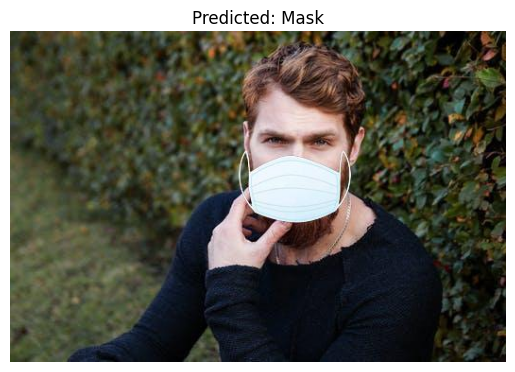

Prediction and display function tested successfully.


In [ ]:
print("Testing the prediction and display function...")

# Define the image path for testing
test_image_path = "/content/data/datasets/debarghamitraroy/face-mask-detection/versions/1/data/with_mask/with_mask_1.jpg"

# Call the display_prediction function
display_prediction(test_image_path, model, trasnform, device)

print("Prediction and display function tested successfully.")

## Summary:

### Data Analysis Key Findings

*   A Python function, `predict_image`, was successfully created to load an image, apply predefined transformations, make a prediction using a trained PyTorch model, and return the predicted class label (0 for 'Without Mask' and 1 for 'Mask').
*   Another function, `display_prediction`, was implemented to integrate the prediction logic with image visualization. This function uses `predict_image` to obtain the prediction and then employs `matplotlib.pyplot` to display the input image with its predicted class (e.g., "Predicted: Mask") as the title.
*   The entire prediction and display pipeline was successfully tested using the image located at `/content/data/datasets/debarghamitraroy/face-mask-detection/versions/1/eval/test_309.jpg`, demonstrating the functionality to visually present the model's prediction.

### Insights or Next Steps

*   The established prediction and visualization functions provide a robust way to qualitatively assess the model's performance on individual images, aiding in quick verification and debugging.
*   The next step could involve expanding this functionality to perform batch predictions on an entire evaluation dataset and calculating quantitative performance metrics (e.g., accuracy, precision, recall) to provide a comprehensive assessment of the model's generalization capabilities.
